In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

#--------------------------------------------------------------------

bonsai_folder = "/scratch/elena/9Li/results/run1848/bonsai_output"
bonsai_files = sorted(glob(f"{bonsai_folder}/*_bonsai.csv"))
print("Found BONSAI CSVs:", bonsai_files)
print(len(bonsai_files))


Found BONSAI CSVs: ['/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_0_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_10_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_11_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_12_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_13_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_14_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_15_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_16_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_17_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_18_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_output/Li9_clusters_chunk_19_bonsai.csv', '/scratch/elena/9Li/results/run1848/bonsai_out

In [2]:
dfs = [pd.read_csv(f) for f in bonsai_files]
df_all = pd.concat(dfs, ignore_index=True)

print("Total clusters loaded:", len(df_all))
df_all.head()

Total clusters loaded: 633528


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,vertex_x,vertex_y,vertex_z
0,1.600714e+10,82126.521969,39,0,"[34, 32, 26, 26, 26, 23, 16, 16, 83, 83, 17, 9...","[78, 75, 60, 60, 60, 47, 73, 73, 28, 28, 29, 1...","[0, 7, 6, 10, 12, 9, 4, 13, 14, 0, 6, 11, 0, 7...","[17, 2, 8, 10, 4, 3, 1, 12, 13, 17, 8, 11, 17,...","[16007140414.384735, 16007140411.615402, 16007...","[106.0, 149.0, 103.0, 140.0, 190.0, 82.0, 109....",0.000000,0.000000,5.170791e-43
1,1.600714e+10,85972.235668,25,0,"[16, 21, 21, 98, 47, 99, 99, 19, 1, 27, 11, 46...","[73, 64, 64, 100, 13, 90, 90, 41, 70, 2, 10, 4...","[3, 5, 15, 11, 16, 5, 8, 2, 7, 0, 8, 9, 2, 9, ...","[18, 7, 5, 11, 14, 7, 9, 0, 2, 17, 9, 3, 0, 3,...","[16007144267.85772, 16007144256.741348, 160071...","[97.0, 124.0, 74.0, 183.0, 137.0, 157.0, 219.0...",-17.749630,57.972412,-1.631707e+01
2,1.600717e+10,111298.247068,39,0,"[26, 80, 80, 73, 44, 107, 99, 1, 22, 22, 14, 4...","[60, 30, 30, 31, 43, 44, 90, 70, 82, 82, 53, 7...","[5, 18, 2, 4, 15, 0, 17, 3, 1, 17, 18, 0, 2, 2...","[7, 16, 0, 1, 5, 17, 15, 18, 6, 15, 16, 17, 0,...","[16007169593.366247, 16007169587.131247, 16007...","[57.0, 83.0, 260.0, 182.0, 154.0, 134.0, 405.0...",47.797157,-209.582993,2.377424e+02
3,1.600717e+10,113628.748404,39,0,"[26, 23, 16, 15, 73, 47, 99, 1, 87, 8, 8, 11, ...","[60, 47, 73, 58, 31, 13, 90, 70, 88, 84, 84, 1...","[14, 14, 3, 15, 12, 13, 4, 4, 3, 3, 6, 3, 11, ...","[13, 13, 18, 5, 4, 12, 1, 1, 18, 18, 8, 18, 11...","[16007171916.884207, 16007171917.886374, 16007...","[125.0, 138.0, 101.0, 109.0, 143.0, 350.0, 136...",-130.567749,-62.757183,2.388486e+02
4,1.600719e+10,129177.227371,39,0,"[23, 16, 16, 16, 83, 103, 89, 111, 111, 111, 9...","[47, 73, 73, 73, 28, 98, 89, 97, 97, 97, 90, 9...","[3, 1, 17, 14, 11, 1, 18, 11, 7, 10, 2, 18, 1,...","[18, 6, 15, 13, 11, 6, 16, 11, 2, 10, 0, 16, 6...","[16007187464.494902, 16007187462.976036, 16007...","[169.0, 64.0, 63.0, 132.0, 122.0, 149.0, 186.0...",90.705643,-64.530540,-2.388486e+02


In [15]:
# radius
df_all["r"] = np.sqrt(df_all["vertex_x"]**2 + df_all["vertex_z"]**2)

# filtered dataset
df_good = df_all[
    np.isfinite(df_all["vertex_x"]) &
    np.isfinite(df_all["vertex_y"]) &
    np.isfinite(df_all["vertex_z"]) &
    (df_all["r"] > 1e-2) &
    (df_all["r"] < 1000)
].copy()

# beam reference
beam = np.array([0.0, -42.47, 138.79])

# distances
dx = df_good["vertex_x"] - beam[0]
dy = df_good["vertex_y"] - beam[1]
dz = df_good["vertex_z"] - beam[2]

df_good["beam_dist"] = np.sqrt(dx**2 + dy**2 + dz**2)

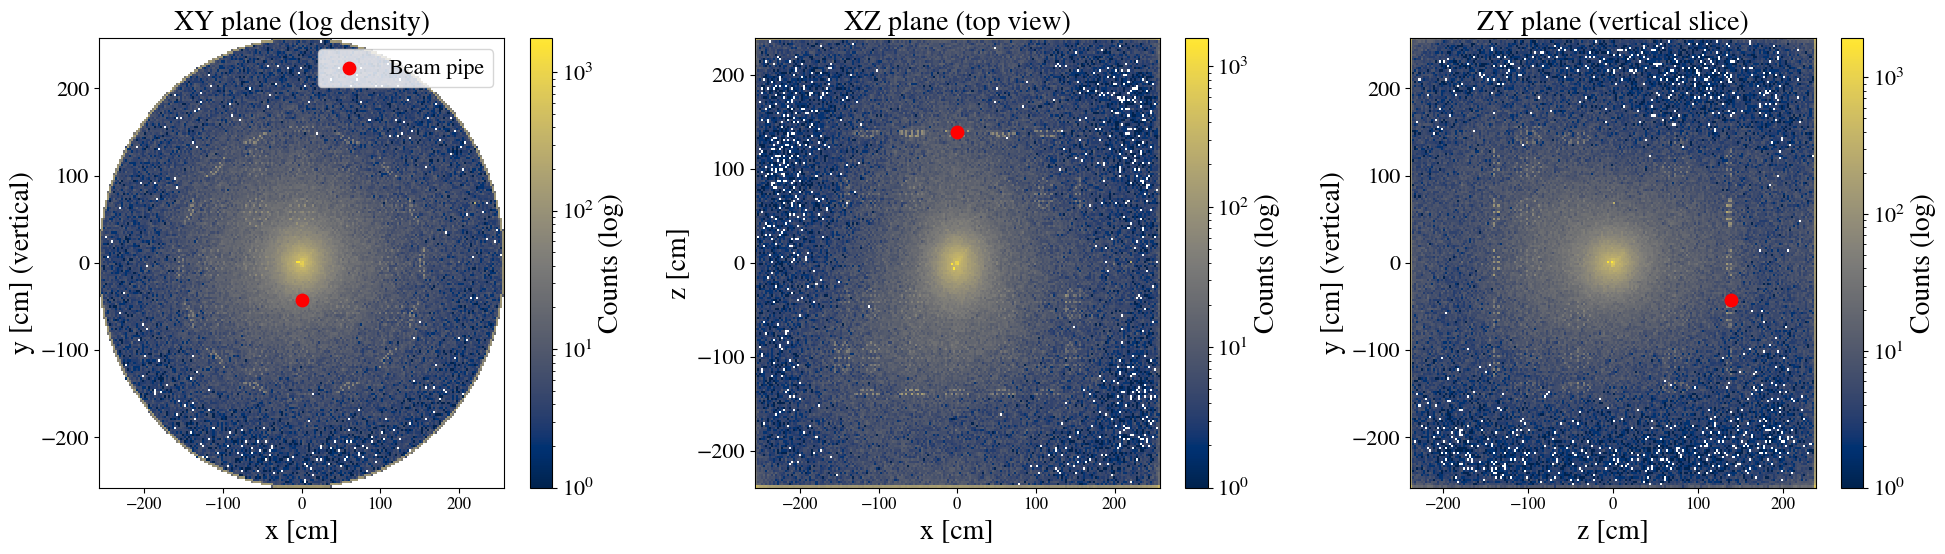

In [17]:
import matplotlib.pyplot as plt
import numpy as np

x = df_good["vertex_x"]
y = df_good["vertex_y"]
z = df_good["vertex_z"]

beam = np.array([0.0, -42.47, 138.79])

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# =========================================================
# 1. XY plane
# =========================================================
h1 = axs[0].hist2d(
    x, y,
    bins=200,
    cmap="cividis",
    norm="log"
)

axs[0].scatter(beam[0], beam[1], color="red", s=80, label="Beam pipe")
axs[0].set_xlabel("x [cm]")
axs[0].set_ylabel("y [cm] (vertical)")
axs[0].set_title("XY plane (log density)")
axs[0].legend()

cbar1 = plt.colorbar(h1[3], ax=axs[0])
cbar1.set_label("Counts (log)")

# =========================================================
# 2. XZ plane (top view)
# =========================================================
h2 = axs[1].hist2d(
    x, z,
    bins=200,
    cmap="cividis",
    norm="log"
)

axs[1].scatter(beam[0], beam[2], color="red", s=80)
axs[1].set_xlabel("x [cm]")
axs[1].set_ylabel("z [cm]")
axs[1].set_title("XZ plane (top view)")

cbar2 = plt.colorbar(h2[3], ax=axs[1])
cbar2.set_label("Counts (log)")

# =========================================================
# 3. ZY plane (vertical slice)
# =========================================================
h3 = axs[2].hist2d(
    z, y,
    bins=200,
    cmap="cividis",
    norm="log"
)

axs[2].scatter(beam[2], beam[1], color="red", s=80)
axs[2].set_xlabel("z [cm]")
axs[2].set_ylabel("y [cm] (vertical)")
axs[2].set_title("ZY plane (vertical slice)")

cbar3 = plt.colorbar(h3[3], ax=axs[2])
cbar3.set_label("Counts (log)")

plt.tight_layout()
plt.show()

In [23]:
R_MAX = 153.7963
Y_MAX = 135.711175

r = np.sqrt(df_good["vertex_x"]**2 + df_good["vertex_z"]**2)

inside = (
    (r < R_MAX) &
    (np.abs(df_good["vertex_y"]) < Y_MAX)
)

outside = ~inside

x_in = df_good.loc[inside, "vertex_x"]
y_in = df_good.loc[inside, "vertex_y"]
z_in = df_good.loc[inside, "vertex_z"]

x_out = df_good.loc[outside, "vertex_x"]
y_out = df_good.loc[outside, "vertex_y"]
z_out = df_good.loc[outside, "vertex_z"]

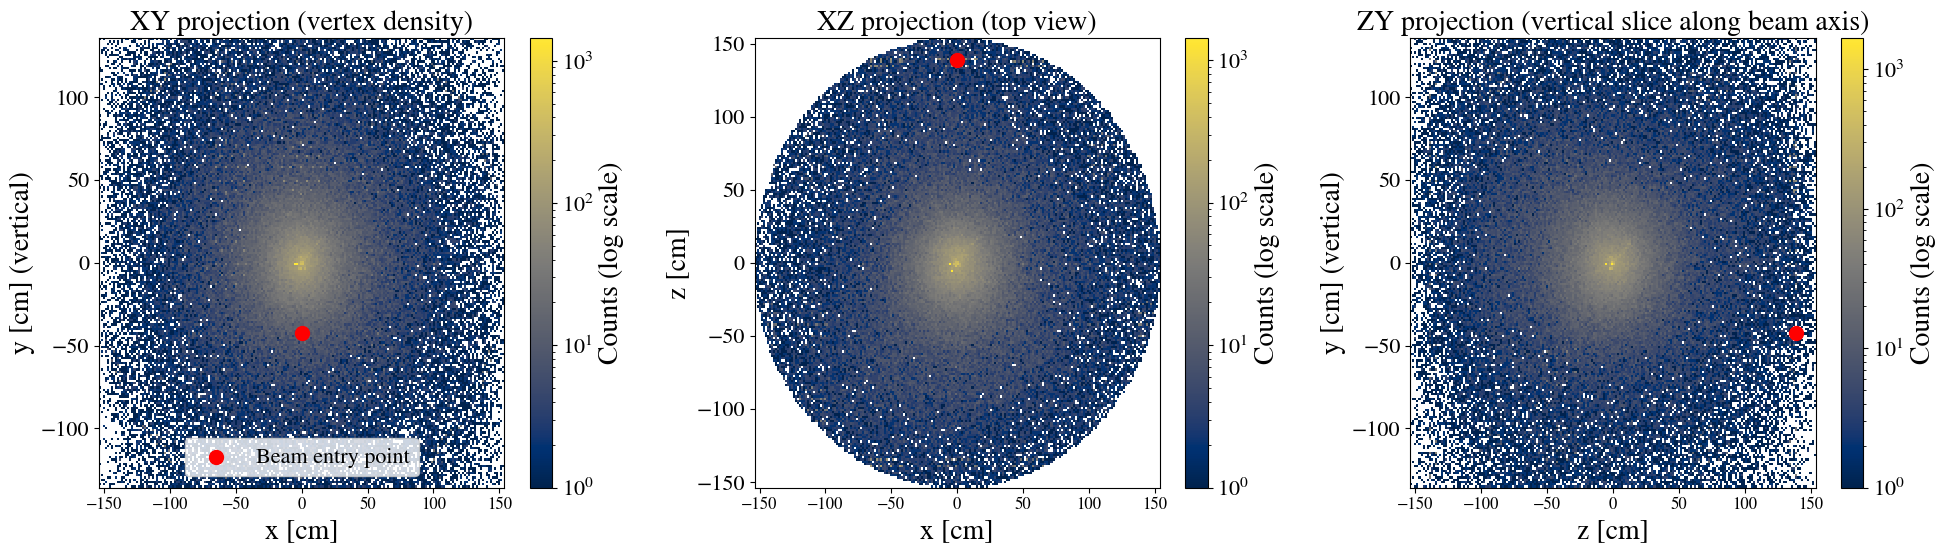

In [27]:
import matplotlib.pyplot as plt
import numpy as np

beam = np.array([0.0, -42.47, 138.79])

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# =========================================================
# 1. XY plane (x vs y)
# =========================================================
h1 = axs[0].hist2d(
    x_in, y_in,
    bins=200,
    cmap="cividis",
    norm="log"
)

# outside (kept but invisible)
axs[0].scatter(x_out, y_out, s=1, color="white", alpha=0.0)

axs[0].scatter(
    beam[0], beam[1],
    color="red", s=100, label="Beam entry point"
)

axs[0].set_xlabel("x [cm]")
axs[0].set_ylabel("y [cm] (vertical)")
axs[0].set_title("XY projection (vertex density)")

axs[0].legend()
plt.colorbar(h1[3], ax=axs[0], label="Counts (log scale)")


# =========================================================
# 2. XZ plane (top view)
# =========================================================
h2 = axs[1].hist2d(
    x_in, z_in,
    bins=200,
    cmap="cividis",
    norm="log"
)

axs[1].scatter(x_out, z_out, s=1, color="white", alpha=0.0)

axs[1].scatter(
    beam[0], beam[2],
    color="red", s=100
)

axs[1].set_xlabel("x [cm]")
axs[1].set_ylabel("z [cm]")
axs[1].set_title("XZ projection (top view)")

plt.colorbar(h2[3], ax=axs[1], label="Counts (log scale)")


# =========================================================
# 3. ZY plane (beam + vertical structure)
# =========================================================
h3 = axs[2].hist2d(
    z_in, y_in,
    bins=200,
    cmap="cividis",
    norm="log"
)

axs[2].scatter(z_out, y_out, s=1, color="white", alpha=0.0)

axs[2].scatter(
    beam[2], beam[1],
    color="red", s=100
)

axs[2].set_xlabel("z [cm]")
axs[2].set_ylabel("y [cm] (vertical)")
axs[2].set_title("ZY projection (vertical slice along beam axis)")

plt.colorbar(h3[3], ax=axs[2], label="Counts (log scale)")


plt.tight_layout()
plt.show()

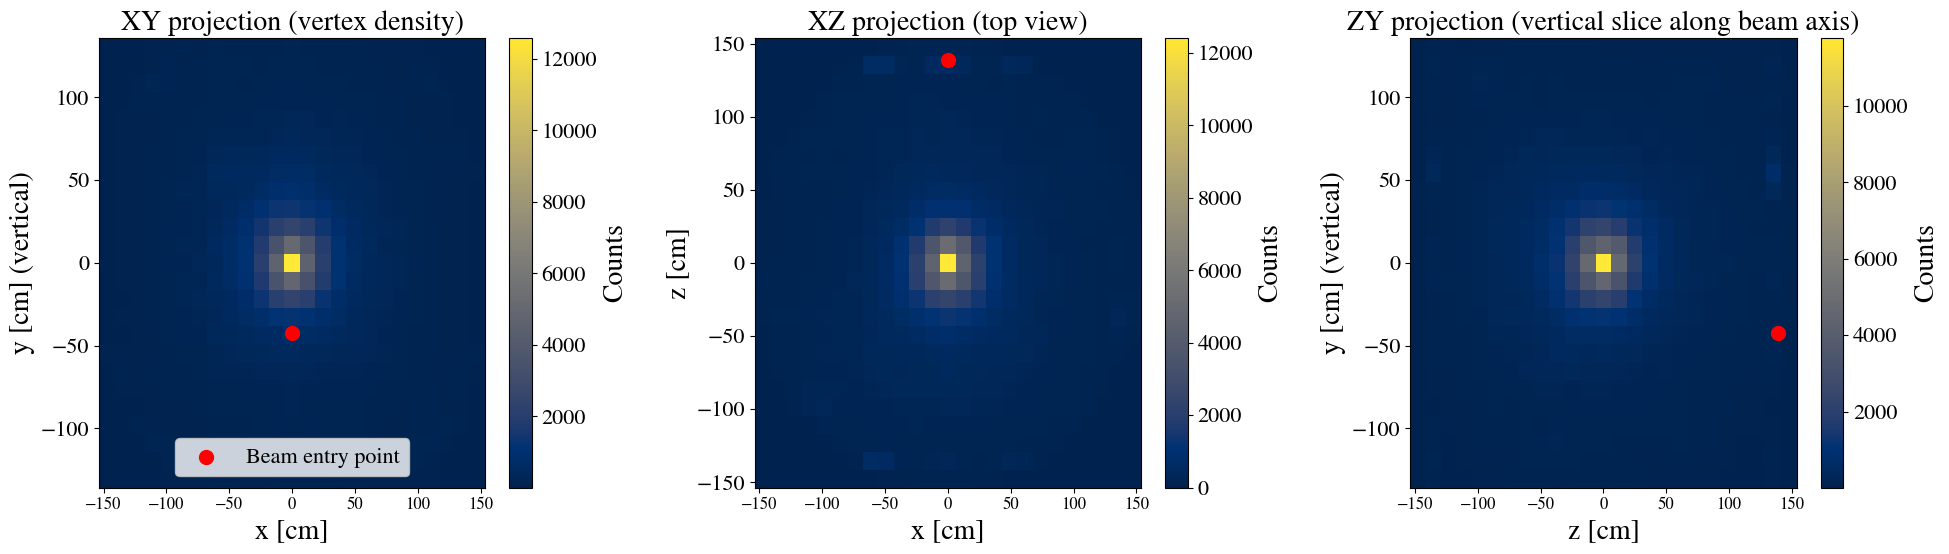

In [28]:
import matplotlib.pyplot as plt
import numpy as np

beam = np.array([0.0, -42.47, 138.79])

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# =========================================================
# 1. XY plane (x vs y)
# =========================================================
h1 = axs[0].hist2d(
    x_in, y_in,
    bins=25,
    cmap="cividis"
)

axs[0].scatter(x_out, y_out, s=1, color="white", alpha=0.0)

axs[0].scatter(
    beam[0], beam[1],
    color="red", s=100, label="Beam entry point"
)

axs[0].set_xlabel("x [cm]")
axs[0].set_ylabel("y [cm] (vertical)")
axs[0].set_title("XY projection (vertex density)")

axs[0].legend()
plt.colorbar(h1[3], ax=axs[0], label="Counts")


# =========================================================
# 2. XZ plane (top view)
# =========================================================
h2 = axs[1].hist2d(
    x_in, z_in,
    bins=25,
    cmap="cividis"
)

axs[1].scatter(x_out, z_out, s=1, color="white", alpha=0.0)

axs[1].scatter(
    beam[0], beam[2],
    color="red", s=100
)

axs[1].set_xlabel("x [cm]")
axs[1].set_ylabel("z [cm]")
axs[1].set_title("XZ projection (top view)")

plt.colorbar(h2[3], ax=axs[1], label="Counts")


# =========================================================
# 3. ZY plane (beam + vertical structure)
# =========================================================
h3 = axs[2].hist2d(
    z_in, y_in,
    bins=25,
    cmap="cividis"
)

axs[2].scatter(z_out, y_out, s=1, color="white", alpha=0.0)

axs[2].scatter(
    beam[2], beam[1],
    color="red", s=100
)

axs[2].set_xlabel("z [cm]")
axs[2].set_ylabel("y [cm] (vertical)")
axs[2].set_title("ZY projection (vertical slice along beam axis)")

plt.colorbar(h3[3], ax=axs[2], label="Counts")


plt.tight_layout()
plt.show()